In [1]:
import os, re
import numpy as np
import scanpy as sc
from os.path import join
import pandas as pd
import shutil

import sys
import scipy.io as sio
import paste as pst
import scipy.sparse as sps
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.metrics import adjusted_rand_score

In [3]:
def stack_obs(_dir):
    fds = os.listdir(_dir)
    _obs = []
    for fd in fds:
        if fd.startswith("R"):
            continue
        fns = os.listdir(join(_dir, fd))
        adx = sc.read_h5ad(join(_dir, fd, fns[0]))
        _obs.append(adx.obs)
    df = pd.concat(_obs)
    return df

In [8]:
target_methods = [
    'CLUE',
    'StabMap',
    'SpaMosaic(non-spatial)',
    'UINMF',
    'scMoMaT',
    'SpaMosaic',
    'MIDAS',
    'Cobolt',
    'MultiVI'
]

data_dir = '../../data/processed/'
emb_dir = '../../results/embeddings/'
score_dir = '../../results/scores/'

In [9]:
ds = 'Lymph-S1-S2-S3'

filtered_methods = [m for m in target_methods if os.path.exists(join(emb_dir, m, ds, 'df_emb.csv'))]
df_embs = []
for meth in filtered_methods:
    df_embs.append(pd.read_csv(join(emb_dir, meth, ds, 'df_emb.csv'), index_col=0))
    
df_meta = stack_obs(join(data_dir, ds))
comm_idx = df_meta.index.intersection(df_embs[0].index)

adx = sc.AnnData(np.zeros((len(comm_idx), 2)))
adx.obs = df_meta.loc[comm_idx].copy()

for meth, emb in zip(filtered_methods, df_embs):
    adx.obsm[f'{meth}_emb'] = emb.loc[comm_idx].values

In [10]:
sc.pp.neighbors(adx, use_rep=f'SpaMosaic_emb')
sc.tl.umap(adx)

/home/yanxh/anaconda3/envs/torch2.0/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/yanxh/anaconda3/envs/torch2.0/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


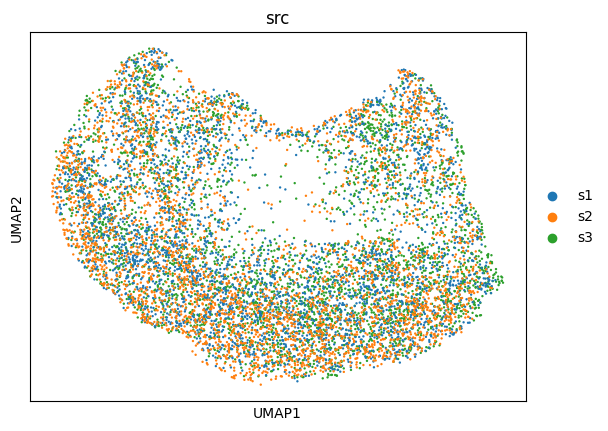

In [11]:
sc.pl.umap(adx, color=['src'])